# GenTag Cleaning, Anchor-Tag Review, and Deal-Breaker Tag Selection

## Business question

This notebook turns a large set of raw GenTag outputs into a smaller, reviewed set of **anchor tags** that are useful for deal-breaker mode in Voraa.

For Voraa, the product question is not simply which tags appear often. The real question is:

> Which tags are concrete, decision-relevant, and broad enough across venues that they could help users quickly rule venues in or out?

That matters because Voraa is a local restaurant and deal discovery app. In this setting, users often make fast filtering decisions under uncertainty. They are not just browsing for interesting places. They are also asking questions such as:

- Can I bring my dog?
- Is parking manageable?
- Is this place quiet enough to talk or work?
- Does it fit dietary needs?
- Will the wait or service friction make the visit not worth it?

A good deal-breaker tag should therefore satisfy two conditions at the same time:

- **Business relevance**: it reflects a real constraint, preference, or usability signal that can change venue choice.
- **Operational usefulness**: it appears consistently enough in the tag system, and across enough venues, to support product features such as filtering, explanation, ranking, or venue summaries.


## What this notebook is designed to do

This notebook builds an interpretable pipeline that:

1. loads and lightly cleans the global GenTag dataset  
2. groups raw tags into broad decision-relevant domains  
3. narrows the review space to buckets that could matter for venue choice  
4. uses embeddings to surface semantically similar wording  
5. builds anchor-based review groups within each bucket  
6. uses the anchor tag from each group as a reviewable candidate signal  
7. merges those anchor tags with the venue-level table to measure venue coverage  
8. uses venue coverage to remove narrower anchor-tag candidates
9. prepares a final shortlist for manual business selection

## What this notebook is **not** trying to do

This notebook is **not** trying to build a perfect taxonomy, ontology, or universal tagging system for restaurants.

It is also **not** trying to fully automate concept naming. The output is meant to support product judgment, not replace it.

The intended outcome is a practical shortlist of anchor tags that are:

- understandable to users
- defensible to stakeholders
- grounded in the data
- plausible to operationalize in the product


## Notebook roadmap and expected outputs

This notebook works in three layers.

### Layer 1: organize the raw tag space
We clean tag text, apply broad grouping rules, and narrow the analysis to the subset of tags that is plausibly relevant to **deal-breaker mode**.

### Layer 2: build reviewable anchor-tag groups
We use embeddings to detect likely wording variants and build **anchor-based review groups** inside each broad bucket. The goal here is not to create a formal concept taxonomy, but to identify strong and interpretable anchor tags that can serve as candidate signals for downstream product review.

### Layer 3: evaluate anchor tags for product use
We bring the surviving anchor tags into the venue-level table, calculate how broadly each anchor signal appears across venues, and then apply practical thresholds to remove weaker candidates. The remaining anchor tags form a shortlist for final manual selection.

## Main inputs

- `gentags_global_deduped.csv`: one row per deduplicated raw tag with support metrics
- `gentags_deduped_by_venue.csv`: venue-level tag data used to measure anchor-tag coverage across venues

## Main outputs produced by the notebook

- anchor-based review groups within decision-relevant buckets
- a filtered anchor-tag table with global support metrics
- venue-level coverage metrics for each surviving anchor tag
- a final shortlist of anchor tags for manual business selection

In [3]:
# Basic data processing
import pandas as pd
import ast
import numpy as np
import re
from collections import Counter

# Display settings for easier inspection
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 200)

### Step 1. Load the global dataset

We start with the **global, tag-level deduplicated dataset**.

At this stage, each row represents a raw GenTag that has already been deduplicated at the tag level, along with support metrics such as how often it appears and how broadly it is supported by the upstream modeling process.

Why start here:

- It gives us a compact view of the tag universe before venue-level expansion.
- It is the right level for semantic cleaning and concept consolidation.
- It lets us evaluate whether a tag family is broadly meaningful before worrying about individual venues.

In other words, this table answers: **what kinds of tags exist, and how much support does each one have overall?**


In [5]:
global_file = "gentags_global_deduped.csv"
global_df = pd.read_csv(global_file)

print("Global dataset shape:", global_df.shape)
print("\nColumns:")
print(global_df.columns.tolist())

global_df.head()

Global dataset shape: (36892, 8)

Columns:
['tag_id', 'tag', 'frequency', 'modelCount', 'wordCount', 'models', 'prompts', 'extraction_run_id']


,tag_id,tag,frequency,modelCount,wordCount,models,prompts,extraction_run_id
0,85ef1cd4-afd7-5cdf-9a38-86aba9477e15,excellent service,2597,4,2,"claude,gemini,grok,openai","anti_hallucination,minimal,short_phrase",week2_run_20251223_191104
1,309d3440-aca7-5a4c-bedf-3e386910a14e,delicious food,2489,4,2,"claude,gemini,grok,openai","anti_hallucination,minimal,short_phrase",week2_run_20251223_191104
2,a382319d-210a-522a-a7d1-28e1f27c4aae,friendly staff,2472,4,2,"claude,gemini,grok,openai","anti_hallucination,minimal,short_phrase",week2_run_20251223_191104
3,632e6107-b25a-5d86-9ae0-97c22e80434c,great service,1779,4,2,"claude,gemini,grok,openai","anti_hallucination,minimal,short_phrase",week2_run_20251223_191104
4,9b3b229b-4e21-5ed6-8ac6-7b90c932b53f,fast service,1271,4,2,"claude,gemini,grok,openai","anti_hallucination,minimal,short_phrase",week2_run_20251223_191104


### Step 2. Run basic sanity checks on the global dataset

Before doing any semantic work, we check the structure of the input table.

These checks are intentionally simple, but they matter for two reasons:

1. They confirm that the file loaded correctly and contains the columns we expect.
2. They give us a quick sense of scale, especially how many rows and how many unique raw tags we are dealing with.

This is important because the rest of the notebook assumes that:

- the dataset is already deduplicated at the tag level
- `tag` is the main text field
- support metrics such as `frequency` and `modelCount` are available for downstream ranking

If something is wrong here, every later step becomes harder to trust.


In [7]:
print("Number of rows:", len(global_df))
print("Unique raw tags:", global_df["tag"].nunique())

print("\nMissing values by column:")
print(global_df.isna().sum())

print("\nDuplicate rows:", global_df.duplicated().sum())

Number of rows: 36892
Unique raw tags: 36892

Missing values by column:
tag_id               0
tag                  0
frequency            0
modelCount           0
wordCount            0
models               0
prompts              0
extraction_run_id    0
dtype: int64

Duplicate rows: 0


### Step 3. Keep only the columns needed for this analysis

The raw file may contain more fields than we need for this workflow.

For this notebook, we keep only the columns that matter for concept selection:

- `tag`: the original raw GenTag text
- `frequency`: how often the tag appears overall
- `modelCount`: how broadly the tag is supported by the extraction process
- `wordCount`: a simple description of text length that can help with inspection

Why narrow the table early:

- it keeps the workflow easier to read
- it reduces distraction from columns that are not used downstream
- it makes the later merges and summaries easier to reason about

This is also an early signal that the notebook is focused on **selection**, not on reconstructing every possible detail of the raw pipeline.


In [9]:
global_keep_cols = [
    "tag",
    "frequency",
    "modelCount",
    "wordCount"
]

global_df = global_df[global_keep_cols].copy()
global_df.head()

,tag,frequency,modelCount,wordCount
0,excellent service,2597,4,2
1,delicious food,2489,4,2
2,friendly staff,2472,4,2
3,great service,1779,4,2
4,fast service,1271,4,2


### Step 4. Normalize raw tags

Before we compare tags semantically, we first standardize their surface form.

This step is deliberately conservative. The goal is to improve consistency, **not** to collapse different meanings too early.

We apply light text normalization:

- lowercase everything
- trim extra whitespace
- normalize accented Latin characters
- convert slashes and hyphens into spaces
- remove extra punctuation
- collapse repeated spaces

Why this matters for the business task:

If semantically similar tags appear in slightly different forms, such as punctuation variants or casing variants, they can artificially fragment support. That makes the tag universe look noisier than it really is and makes later grouping less stable.

At the same time, we do **not** merge meaning here. For example, this step should not decide whether two different phrases belong to the same product concept. That judgment comes later, after we inspect similarity and business meaning.


In [11]:
import unicodedata

def normalize_tag(text):
    if pd.isna(text):
        return np.nan
    
    text = str(text).lower().strip()
    
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    
    text = re.sub(r"[-/]", " ", text)
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

global_df["normalized_tag"] = global_df["tag"].apply(normalize_tag)

global_df[["tag", "normalized_tag"]].tail(10)

,tag,normalized_tag
36882,zero-waste,zero waste
36883,zero-waste cuisine,zero waste cuisine
36884,zesty tiger roll,zesty tiger roll
36885,zinfandel,zinfandel
36886,zombie cocktail,zombie cocktail
36887,zucchini carrots dish,zucchini carrots dish
36888,zucchini dish,zucchini dish
36889,ángel de la independencia,angel de la independencia
36890,ángel views,angel views
36891,árabe taco,arabe taco


In [12]:
global_df["normalized_tag"].duplicated().sum()

790

### Step 5. Aggregate support metrics after tag normalization

After normalizing raw tags into a standardized text form, some tags that originally looked different now collapse into the same `normalized_tag`.

This creates duplication at the normalized level. That duplication is not an error. Instead, it tells us that multiple raw tag forms were expressing the same underlying signal.

If we keep those rows separate, we would underestimate the real support behind that signal. To fix this, we aggregate all rows that share the same `normalized_tag`, sum their support metric `frequency`, and average their support metric `modelCount`.

In [14]:
global_tag_agg = (
    global_df
    .groupby("normalized_tag", as_index=False)
    .agg(
        total_frequency=("frequency", "sum"),
        avg_modelCount=("modelCount", "mean")
    )
    .sort_values("total_frequency", ascending=False)
    .reset_index(drop=True)
)

global_tag_agg.head(10)

,normalized_tag,total_frequency,avg_modelCount
0,excellent service,2597,4.0
1,delicious food,2489,4.0
2,friendly staff,2472,4.0
3,great service,1779,4.0
4,fast service,1271,4.0
5,friendly service,1220,4.0
6,attentive service,1168,4.0
7,good service,1153,4.0
8,slow service,1149,4.0
9,highly recommended,1085,4.0


In [15]:
global_tag_agg["normalized_tag"].duplicated().sum()

0

### Step 6. Apply lightweight keyword-based grouping

At this point, the tag universe is still too broad to review efficiently. We need a fast way to organize tags into broad domains that are more relevant to the product question.

We therefore apply a **lightweight rule-based grouping function**.

Why use a lightweight grouping step at all:

Voraa is trying to identify concepts that can help users make venue decisions. In that context, not every tag deserves equal attention. Some domains are much more likely to contain actionable constraints than others.

For example:

- `parking`, `patio`, `vegan options`, and `quiet` are plausible product-facing decision signals.
- Very broad praise terms or purely descriptive food terms may be interesting, but they are less likely to function as deal-breaker filters.

So this step gives us an **organizational scaffold**. It helps separate likely decision-relevant areas from the rest of the tag space without pretending that the rules are perfect.


In [17]:
def simple_bucket(tag):
    if pd.isna(tag):
        return "other"
    
    tag = str(tag).lower()

    # 1. ambiance, vibe, noise, decor, view
    if any(x in tag for x in [
        "quiet", "noisy", "noise", "loud", "atmosphere", "ambiance", "ambience",
        "vibe", "vibes", "music", "decor", "view", "interior", "setting"
    ]):
        return "ambiance_noise"

    # 2. seating, patio, terrace, venue size, crowding
    if any(x in tag for x in [
        "seating", "seat", "patio", "terrace", "table", "space", "venue",
        "crowded", "chairs", "outdoor", "indoor"
    ]):
        return "seating_space"

    # 3. family, group, date, study/work context
    if any(x in tag for x in [
        "family", "kid", "kids", "group", "friends", "date", "celebration",
        "studying", "working", "focus", "reading", "party"
    ]):
        return "social_context"

    # 4. food quality and ingredients
    if any(x in tag for x in [
        "food", "appetizer", "dish", "meal", "ingredient", "taste", "flavor", "fresh",
        "quality", "delicious", "tasty", "yummy", "cooked", "spicy", "sweet",
        "crispy", "juicy", "tender"
    ]):
        return "food_quality"    

    # 5. alcohol, bar, drinks, smoking, coffeehouse signals
    if any(x in tag for x in [
        "smok", "bar", "wine", "beer", "cocktail", "drink", "coffee", "alcohol",
        "espresso", "latte", "mezcal", "tea"
    ]):
        return "alcohol_smoking"

    # 6. price and value
    if any(x in tag for x in [
        "price", "prices", "priced", "value", "affordable", "expensive",
        "overpriced", "worth", "cheap", "reasonable", "moderate", "fair"
    ]):
        return "price_value"

    # 7. service, wait time, reservations, delivery, ordering
    if any(x in tag for x in [
        "service", "staff", "server", "servers", "waiter", "waitress", "manager",
        "wait", "delivery", "reservation", "booking", "order", "takeout",
        "uber eats", "cashier", "bartender"
    ]):
        return "service_operations"

    # 8. specific dishes / menu items
    if any(x in tag for x in [
        "taco", "pizza", "pasta", "burger", "sushi", "salmon", "ceviche",
        "gelato", "tiramisu", "croissant", "hummus", "latte", "steak", "shrimp",
        "paella", "enchiladas", "barbacoa", "burrito", "cookies", "lemonade", "strawberry"
    ]):
        return "menu_item_specific"

    # 9. menu breadth, dietary options, health-related options
    if any(x in tag for x in [
        "vegan", "vegetarian", "gluten", "keto", "protein", "healthy", "diet",
        "allergy", "menu", "options", "variety", "toppings"
    ]):
        return "menu_dietary"

    # 10. location and neighborhood context
    if any(x in tag for x in [
        "location", "downtown", "center", "distance", "walk", "neighborhood",
        "roma", "monterrey", "pedro", "mexico city"
    ]):
        return "location_context"

    # 11. access / parking / accessibility
    if any(x in tag for x in [
        "parking", "wheelchair", "accessible", "accessibility", "air conditioning",
        "phone signal", "english menu", "language barrier"
    ]):
        return "accessibility_parking"

    # 12. pet friendliness
    if any(x in tag for x in [
        "pet friendly",
        "pets allowed",
        "dog friendly",
        "dogs allowed",
        "cat friendly",
        "cats allowed"
    ]):
        return "pet_friendly"
        
    # 13. cleanliness, hygiene, food safety
    if any(x in tag for x in [
        "clean", "bathroom", "restroom", "hygiene", "poisoning", "raw", "rotten",
        "cockroach", "health risk"
    ]):
        return "cleanliness_safety"
        
    # 14. recommendation / return / endorsement language
    if any(x in tag for x in [
        "recommend", "return", "favorite", "gem", "place", "spot", "must try",
        "must visit"
    ]):
        return "generic_positive"

    # 15. negative churn / dissatisfaction language
    if any(x in tag for x in [
        "not recommended", "not returning", "wont return", "will not return",
        "disappointing", "overrated", "nothing special"
    ]):
        return "generic_negative"

    return "other"

In [18]:
# apply rule buckets
global_tag_agg["bucket"] = global_tag_agg["normalized_tag"].apply(simple_bucket)

global_tag_agg.head(15)

,normalized_tag,total_frequency,avg_modelCount,bucket
0,excellent service,2597,4.0,service_operations
1,delicious food,2489,4.0,food_quality
2,friendly staff,2472,4.0,service_operations
3,great service,1779,4.0,service_operations
4,fast service,1271,4.0,service_operations
5,friendly service,1220,4.0,service_operations
6,attentive service,1168,4.0,service_operations
7,good service,1153,4.0,service_operations
8,slow service,1149,4.0,service_operations
9,highly recommended,1085,4.0,generic_positive


### Step 7. Focus on buckets that are plausibly relevant to deal-breaker mode

After broad grouping, we intentionally narrow the scope to buckets that could realistically influence venue choice.

This is where the notebook becomes more explicitly product-driven.

For a restaurant and deal discovery app, deal-breaker concepts usually come from one of three broad families:

1. **Hard constraints**  
   Examples: pet policy, accessibility, parking, dietary fit, reservation requirement

2. **Strong experience conditions**  
   Examples: noise level, seating setup, wait time, cleanliness, crowding

3. **Context-sensitive fit signals**  
   Examples: family-friendly, group-friendly, date setting, work/study suitability

These are the kinds of concepts that can change a user's decision before they ever read a full review.

We therefore keep a relatively broad set of candidate buckets, such as atmosphere, seating, menu/dietary, price, service/operations, accessibility, and location context. This prevents us from prematurely excluding useful concepts while still keeping the workflow manageable.

The output of this step is **not** the final shortlist. It is the reviewable search space for the next stage.


In [20]:
focus_buckets = [
    "ambiance_noise",
    "seating_space",
    "social_context",
    "pet_friendly",
    "alcohol_smoking",
    "price_value",
    "service_operations",
    "cleanliness_safety",
    "menu_dietary",
    "location_context",
    "accessibility_parking",
    "food_quality",
]

focus_df = global_tag_agg[global_tag_agg["bucket"].isin(focus_buckets)].copy()

### Step 8. Build a candidate tag table within the focus buckets

Now that we have narrowed the search space, we build a compact candidate table for review.

Because the global dataset is already deduplicated at the tag level, we do not need another heavy aggregation step here. Instead, we keep:

- the normalized tag text
- its broad bucket
- its existing support metrics

Why this table matters:

This becomes the main working table for concept discovery. It lets us inspect the strongest tags in each decision-relevant area before we introduce embeddings or manual grouping.

This is also the point where we begin shifting from **raw tag inventory** to **candidate concept review**.


In [22]:
candidate_tags = (
    focus_df[["normalized_tag", "bucket", "total_frequency", "avg_modelCount"]]
    .sort_values(["total_frequency", "avg_modelCount"], ascending=[False, False])
    .reset_index(drop=True)
)

candidate_tags.head(100)

,normalized_tag,bucket,total_frequency,avg_modelCount
0,excellent service,service_operations,2597,4.0
1,delicious food,food_quality,2489,4.0
2,friendly staff,service_operations,2472,4.0
3,great service,service_operations,1779,4.0
4,fast service,service_operations,1271,4.0
5,friendly service,service_operations,1220,4.0
6,attentive service,service_operations,1168,4.0
7,good service,service_operations,1153,4.0
8,slow service,service_operations,1149,4.0
9,attentive staff,service_operations,944,4.0


### Step 9. Inspect the most supported tags within each bucket

Before doing any embedding-based consolidation, it is useful to look at the highest-support tags inside each bucket.

This is a very important interpretive step, not just an exploratory convenience.

Why inspect top tags first:

- It helps us sanity-check whether the bucket rules are catching the right types of content.
- It reveals whether the dominant language in a bucket is concrete or overly generic.
- It gives an early feel for which areas may produce product-usable concepts and which ones may still be too noisy.

From a business perspective, this is where we start asking:

- Are these tags specific enough to support user decision-making?
- Are they understandable enough to become a product-facing concept later?
- Are they dominated by generic sentiment, or do they capture a real constraint or condition?

That judgment becomes even more important later, because high statistical support alone does not guarantee product usefulness.


In [24]:
for bucket in focus_buckets:
    print("\n" + "=" * 80)
    print("BUCKET:", bucket)
    print("=" * 80)
    display(
        candidate_tags[candidate_tags["bucket"] == bucket]
        .sort_values(["total_frequency", "avg_modelCount"], ascending=[False, False])
        .head()
    )


BUCKET: ambiance_noise


,normalized_tag,bucket,total_frequency,avg_modelCount
13,great atmosphere,ambiance_noise,707,4.0
14,cozy atmosphere,ambiance_noise,682,4.0
23,pleasant atmosphere,ambiance_noise,454,4.0
30,live music,ambiance_noise,383,4.0
36,good music,ambiance_noise,318,4.0



BUCKET: seating_space


,normalized_tag,bucket,total_frequency,avg_modelCount
12,outdoor seating,seating_space,776,4.0
49,small space,seating_space,266,4.0
58,small venue,seating_space,221,4.0
60,terrace seating,seating_space,211,4.0
76,indoor seating,seating_space,175,4.0



BUCKET: social_context


...

,normalized_tag,bucket,total_frequency,avg_modelCount
69,great location,location_context,192,4.0
120,convenient location,location_context,120,4.0
165,downtown location,location_context,94,4.0
210,roma norte,location_context,78,4.0
250,downtown austin,location_context,67,4.0



BUCKET: accessibility_parking


,normalized_tag,bucket,total_frequency,avg_modelCount
117,limited parking,accessibility_parking,121,4.0
130,free parking,accessibility_parking,114,4.0
145,ample parking,accessibility_parking,101,4.0
154,no air conditioning,accessibility_parking,97,4.0
191,parking available,accessibility_parking,86,4.0



BUCKET: food_quality


,normalized_tag,bucket,total_frequency,avg_modelCount
1,delicious food,food_quality,2489,4.0
10,great food,food_quality,925,4.0
11,good food,food_quality,870,4.0
17,fresh ingredients,food_quality,568,4.0
18,amazing food,food_quality,506,4.0


#### Why inspect before consolidating

A common failure mode in tag work is to jump too quickly into grouping before understanding what the dominant language actually looks like.

By inspecting high-support tags first, we make the later review-group step safer. It becomes easier to tell whether a proposed merge is genuinely useful or whether it is just bundling vague praise terms together.


### Step 10. Use embeddings to identify likely wording variants

At this point, we already have a focused set of candidate tags inside business-relevant buckets.

The remaining problem is no longer simple cleaning. It is **consolidation**:

Different raw tags may express nearly the same idea, but in slightly different wording. If we treat those as fully separate concepts, we overcount noise and make downstream product decisions harder.

Examples of the kind of redundancy we want to catch:

- phrasing variants of the same parking issue
- multiple ways of expressing noise or quietness
- related wording around pet policy, wait time, or dietary constraints

The job of embeddings here is very specific:

- **help us spot likely merge candidates**
- **reduce repetitive manual review**
- **keep semantically related wording close together**

In [27]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import ast

We use `all-MiniLM-L6-v2` because it provides a strong balance between semantic quality and efficiency for short text. Since our data consists of brief tags, this model is well-suited to capture similarity between phrases with different wording but similar meaning, such as "outdoor seating" and "patio seating". At the same time, it is lightweight and fast, making it practical to compute embeddings at scale. In this pipeline, embeddings are used as a support tool to surface similar tags and reduce manual effort, rather than to fully automate grouping decisions.

In [29]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

#### Encode candidate tags into embeddings

Each tag is converted into a dense semantic vector.

This gives us a representation that is useful for catching related meaning even when the wording is not exactly the same. In practice, this is what makes it possible to group nearby phrases that users or the tagging system may express differently.

In [31]:
tag_texts = candidate_tags["normalized_tag"].tolist()
tag_embeddings = embedding_model.encode(tag_texts, show_progress_bar=True)

tag_embeddings.shape

Batches:   0%|          | 0/517 [00:00<?, ?it/s]

(16539, 384)

#### Compute cosine similarity between candidate tags

Once all candidate tags are embedded, we compute pairwise cosine similarity.

This produces a reusable similarity matrix that supports the next step: building review groups inside each business bucket.

We only use this similarity signal as a way to find likely wording families. The final concept boundary still comes from review and business judgment.


In [33]:
similarity_matrix = cosine_similarity(tag_embeddings)
similarity_matrix.shape

(16539, 16539)

In [34]:
similarity_matrix

array([[0.99999976, 0.30362713, 0.30046117, ..., 0.3532643 , 0.0721719 ,
        0.19085869],
       [0.30362713, 1.0000001 , 0.19351843, ..., 0.639478  , 0.37072754,
        0.24755478],
       [0.30046117, 0.19351843, 0.99999994, ..., 0.19840828, 0.06685719,
        0.17412788],
       ...,
       [0.3532643 , 0.639478  , 0.19840828, ..., 0.99999994, 0.24436608,
        0.21958342],
       [0.0721719 , 0.37072754, 0.06685719, ..., 0.24436608, 1.        ,
        0.2813361 ],
       [0.19085869, 0.24755478, 0.17412788, ..., 0.21958342, 0.2813361 ,
        1.0000001 ]], dtype=float32)

### Step 11. Build anchor-based review groups

#### The grouping rule

Within each broad bucket:

1. sort tags by support, so higher-signal tags are considered first
2. let the highest-priority unassigned tag become the **anchor**
3. attach other tags in the same bucket if they are sufficiently similar to that anchor
4. assign each raw tag to only one group

#### Why this is better for this project

This anchor-based approach is more business-safe than generic connected-component clustering:

- it avoids long similarity chains that can accidentally over-merge concepts
- it keeps one clear representative phrase at the center of each group
- it makes manual review easier because every group starts from an interpretable anchor tag
- it removes the need for auto-generated labels that often add complexity without adding trust

The anchor tag is not automatically the final product concept name, but it is a much better draft starting point than an opaque cluster id or a POS-derived summary word.


---
#### Example: How the anchor-based grouping works

Suppose within the **seating_space** bucket we have the following tags (sorted by support):

- outdoor seating (1200)  
- patio seating (900)  
- outdoor patio (850)  
- rooftop seating (400)  
- crowded space (300)  

##### Step-by-step grouping

1. **Start with the highest-support tag as anchor**  
   → anchor = *outdoor seating*

2. **Attach similar tags to this anchor**  
   - "patio seating" → very similar → attach  
   - "outdoor patio" → very similar → attach  
   - "rooftop seating" → somewhat different → do not attach  
   - "crowded space" → different meaning → do not attach  

   → Group 1:
   - outdoor seating (anchor)  
   - patio seating  
   - outdoor patio  

3. **Move to the next unassigned tag**  
   → next anchor = *rooftop seating*

   → Group 2:
   - rooftop seating  

4. **Continue**  
   → next anchor = *crowded space*

   → Group 3:
   - crowded space  

#### Why this is better than generic clustering

If we used connected-component clustering based only on similarity:

- "outdoor seating" ≈ "patio seating"  
- "patio seating" ≈ "rooftop seating"  

These links could create a chain:

→ outdoor seating → patio seating → rooftop seating  

Result: all three get merged into one cluster

But this is **not business-correct**, because:
- "outdoor seating" and "rooftop seating" can imply different user preferences
- merging them removes useful decision signals

#### What the anchor method fixes

- It **prevents chain merging** because everything must be directly similar to the anchor  
- It keeps a **clear center concept** ("outdoor seating")  
- It produces groups that are **easy to review and rename**  
- It aligns better with how a product would define **deal-breaker features**

In [37]:
GROUP_SIMILARITY_THRESHOLD = 0.6

We set `GROUP_SIMILARITY_THRESHOLD = 0.6` as a balanced cutoff between semantic precision and coverage. 

In practice, similarity scores above 0.8 tend to only capture near-duplicates (for example, “excellent service” vs. “great service”), which can be too strict and fragment meaningful variants into separate groups. On the other hand, scores below 0.5 often begin to include loosely related or contextually different phrases, increasing the risk of over-merging distinct concepts. 

A threshold around 0.6 allows us to group tags that are clearly describing the same underlying idea while still preventing long similarity chains that could blur important distinctions. This makes the resulting groups both interpretable for manual review and reliable for downstream product decisions.

In [39]:
def build_anchor_review_groups(df, sim_matrix, threshold=0.6):
    """
    Build anchor-based review groups within each broad bucket.

    Logic:
    - Process tags within each bucket only
    - Sort by support so high-signal tags become anchors first
    - Attach other unassigned tags whose similarity to the anchor exceeds the threshold
    - Assign each tag to only one group

    This produces review-friendly groups centered on a representative tag.
    """
    group_rows = []
    group_id = 0

    for bucket in df["bucket"].dropna().unique():
        bucket_df = (
            df[df["bucket"] == bucket]
            .sort_values(
                ["total_frequency", "avg_modelCount", "normalized_tag"],
                ascending=[False, False, True]
            )
            .copy()
        )

        bucket_indices = bucket_df.index.tolist()
        assigned = set()

        for anchor_idx in bucket_indices:
            if anchor_idx in assigned:
                continue

            anchor_row = df.loc[anchor_idx]
            member_indices = [anchor_idx]
            member_scores = [1.0]
            assigned.add(anchor_idx)

            for idx in bucket_indices:
                if idx in assigned:
                    continue

                sim_score = float(sim_matrix[anchor_idx, idx])
                if sim_score >= threshold:
                    member_indices.append(idx)
                    member_scores.append(sim_score)
                    assigned.add(idx)

            members = (
                df.loc[member_indices]
                .copy()
                .assign(anchor_similarity=member_scores)
                .sort_values(
                    ["total_frequency", "avg_modelCount", "normalized_tag"],
                    ascending=[False, False, True]
                )
            )

            group_rows.append({
                "group_id": group_id,
                "bucket": bucket,
                "anchor_tag": anchor_row["normalized_tag"],
                "anchor_frequency": anchor_row["total_frequency"],
                "group_size": len(members),
                "group_total_frequency": members["total_frequency"].sum(),
                "avg_anchor_similarity": members["anchor_similarity"].mean(),
                "member_tags": members["normalized_tag"].tolist(),
                "member_support_preview": [
                    {
                        "tag": row["normalized_tag"],
                        "frequency": row["total_frequency"],
                        "modelCount": row["avg_modelCount"],
                        "anchor_similarity": round(float(row["anchor_similarity"]), 3)
                    }
                    for _, row in members.iterrows()
                ]
            })
            group_id += 1

    return pd.DataFrame(group_rows)

In [40]:
review_groups = build_anchor_review_groups(
    candidate_tags,
    similarity_matrix,
    threshold=GROUP_SIMILARITY_THRESHOLD
)

print("Number of review groups:", len(review_groups))
review_groups.head(20)

Number of review groups: 2557


,group_id,bucket,anchor_tag,anchor_frequency,group_size,group_total_frequency,avg_anchor_similarity,member_tags,member_support_preview
0,0,service_operations,excellent service,2597,84,8639,0.708898,"[excellent service, great service, friendly service, good service, terrible service, amazing service, outstanding service, very good service, fantastic service, superb service, nice service, ok se...","[{'tag': 'excellent service', 'frequency': 2597, 'modelCount': 4.0, 'anchor_similarity': 1.0}, {'tag': 'great service', 'frequency': 1779, 'modelCount': 4.0, 'anchor_similarity': 0.928}, {'tag': '..."
1,1,service_operations,friendly staff,2472,304,7615,0.690210,"[friendly staff, attentive staff, helpful staff, knowledgeable staff, kind staff, rude staff, nice staff, welcoming staff, accommodating staff, patient staff, unfriendly staff, friendly waiters, g...","[{'tag': 'friendly staff', 'frequency': 2472, 'modelCount': 4.0, 'anchor_similarity': 1.0}, {'tag': 'attentive staff', 'frequency': 944, 'modelCount': 4.0, 'anchor_similarity': 0.635}, {'tag': 'he..."
2,2,service_operations,fast service,1271,110,4469,0.700494,"[fast service, slow service, quick service, poor service, efficient service, top notch service, rushed service, timely service, worst service, consistent service, basic service, service could be b...","[{'tag': 'fast service', 'frequency': 1271, 'modelCount': 4.0, 'anchor_similarity': 1.0}, {'tag': 'slow service', 'frequency': 1149, 'modelCount': 4.0, 'anchor_similarity': 0.791}, {'tag': 'quick ..."
3,3,service_operations,attentive service,1168,74,1695,0.716403,"[attentive service, inattentive service, attentive server, attentive servers, attentive waiter, attentive manager, courteous service, attentive wait staff, friendly attentive service, service with...","[{'tag': 'attentive service', 'frequency': 1168, 'modelCount': 4.0, 'anchor_similarity': 1.0}, {'tag': 'inattentive service', 'frequency': 80, 'modelCount': 4.0, 'anchor_similarity': 0.608}, {'tag..."
4,4,service_operations,long wait times,270,87,868,0.706145,"[long wait times, long wait, long wait time, short wait, short wait time, long waits, no waiting time, short wait times, 40 minute wait, wait time, wait times, hour wait, long waiting time, no lon...","[{'tag': 'long wait times', 'frequency': 270, 'modelCount': 4.0, 'anchor_similarity': 1.0}, {'tag': 'long wait', 'frequency': 195, 'modelCount': 4.0, 'anchor_similarity': 0.821}, {'tag': 'long wai..."
5,5,service_operations,exceptional service,268,23,531,0.703084,"[exceptional service, bad service, horrible service, unbelievable service, memorable service, awful service, exceptional server, awkward service, shameful service, exceptional customer service, ou...","[{'tag': 'exceptional service', 'frequency': 268, 'modelCount': 4.0, 'anchor_similarity': 1.0}, {'tag': 'bad service', 'frequency': 116, 'modelCount': 4.0, 'anchor_similarity': 0.612}, {'tag': 'ho..."
6,6,service_operations,english speaking staff,144,17,179,0.784638,"[english speaking staff, bilingual staff, helpful english speaking staff, english speaking waiter, multilingual staff, staff speak english, english speaking service, staff speaks english, english ...","[{'tag': 'english speaking staff', 'frequency': 144, 'modelCount': 4.0, 'anchor_similarity': 1.0}, {'tag': 'bilingual staff', 'frequency': 9, 'modelCount': 3.0, 'anchor_similarity': 0.685}, {'tag'..."
7,7,service_operations,inconsistent service,141,26,249,0.715013,"[inconsistent service, service issues, accommodating service, service inconsistency, incompetent service, unresponsive service, service issue, service problem, problematic service, service inconsi...","[{'tag': 'inconsistent service', 'frequency': 141, 'modelCount': 4.0, 'anchor_similarity': 1.0}, {'tag': 'service issues', 'frequency': 19, 'modelCount': 3.0, 'anchor_similarity': 0.77}, {'tag': '..."
8,8,service_operations,professional service,135,19,405,0.684221,"[professional service, kind service, polite service, mediocre service,

This table summarizes the results of the anchor-based grouping step. Each row represents one group of semantically similar tags within a bucket.

- `group_id`: A unique identifier for each group.
  - Each group corresponds to one anchor-centered cluster
  - Used for tracking, review, and downstream mapping

- `bucket`: The high-level category assigned earlier using rule-based grouping.
  - This ensures grouping only happens within comparable semantic areas.

- `anchor_tag`: The representative tag for the group.
  - This is the highest-support unassigned tag selected first
  - It serves as the center of the group
  - All other tags in the group must be similar to this tag

  * Important: This is **not automatically the final concept name**, but it is the starting point for interpretation.

- `anchor_frequency`: The support (frequency) of the anchor tag itself.
  - Indicates how strong this core signal is independently
  - Higher values mean the concept is more prominent in the dataset

- `group_size`: Number of tags assigned to this group.
  - Includes the anchor + all attached tags
  - Larger size may indicate more linguistic variation around the concept

-  `group_total_frequency`: Total support of the entire group.
    - Sum of frequencies of all member tags
    - Represents the **true combined strength** of this concept

- `avg_anchor_similarity`: Average cosine similarity between the anchor tag and all other tags in the group.
  - Measures how tightly the group is clustered
  - Higher values → more semantically consistent group
  - Lower values → more diverse or borderline matches

- `member_tags`: A list of all tags included in this group.
  - These are the raw normalized tags assigned to the anchor
  - Shows how different surface forms map to the same concept

-  `member_support_preview`: A preview of detailed information for some member tags. Each item typically includes:
     - `tag`: the original tag
     - `frequency`: its support
     - `modelCount`: how many models supported it
     - `anchor_similarity`: similarity to the anchor

#### Prioritize the groups that actually deserve review time

Not every group needs equal attention.

Some groups are useful because they contain multiple wording variants.
Others are still worth reviewing even as singletons because the anchor tag itself has strong support and may represent a product-relevant concept.

We therefore keep a simple priority rule:

- keep groups with more than one tag, because they clearly capture wording consolidation
- also keep single-tag groups when the anchor itself is strong enough to matter

This rule is intentionally practical, not theoretical.
Its purpose is to make review effort proportional to likely business value.

In [43]:
review_groups_filtered = review_groups[
    (
        (review_groups["group_size"] >= 2) |
        (review_groups["anchor_frequency"] >= 200)
    ) 
].copy()

review_groups_filtered = review_groups_filtered.sort_values(
    ["group_total_frequency", "anchor_frequency", "group_size"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("Groups kept for review:", len(review_groups_filtered))
review_groups_filtered.head(20)

Groups kept for review: 1511


,group_id,bucket,anchor_tag,anchor_frequency,group_size,group_total_frequency,avg_anchor_similarity,member_tags,member_support_preview
0,348,food_quality,delicious food,2489,417,11875,0.666894,"[delicious food, great food, good food, amazing food, excellent food, delicious drinks, delicious, tasty food, fresh food, mediocre food, delicious pizza, delicious desserts, flavorful food, delic...","[{'tag': 'delicious food', 'frequency': 2489, 'modelCount': 4.0, 'anchor_similarity': 1.0}, {'tag': 'great food', 'frequency': 925, 'modelCount': 4.0, 'anchor_similarity': 0.705}, {'tag': 'good fo..."
1,0,service_operations,excellent service,2597,84,8639,0.708898,"[excellent service, great service, friendly service, good service, terrible service, amazing service, outstanding service, very good service, fantastic service, superb service, nice service, ok se...","[{'tag': 'excellent service', 'frequency': 2597, 'modelCount': 4.0, 'anchor_similarity': 1.0}, {'tag': 'great service', 'frequency': 1779, 'modelCount': 4.0, 'anchor_similarity': 0.928}, {'tag': '..."
2,1,service_operations,friendly staff,2472,304,7615,0.690210,"[friendly staff, attentive staff, helpful staff, knowledgeable staff, kind staff, rude staff, nice staff, welcoming staff, accommodating staff, patient staff, unfriendly staff, friendly waiters, g...","[{'tag': 'friendly staff', 'frequency': 2472, 'modelCount': 4.0, 'anchor_similarity': 1.0}, {'tag': 'attentive staff', 'frequency': 944, 'modelCount': 4.0, 'anchor_similarity': 0.635}, {'tag': 'he..."
3,1251,ambiance_noise,great atmosphere,707,158,5274,0.692776,"[great atmosphere, cozy atmosphere, pleasant atmosphere, relaxed atmosphere, good atmosphere, nice atmosphere, fun atmosphere, lively atmosphere, warm atmosphere, quiet atmosphere, comfortable atm...","[{'tag': 'great atmosphere', 'frequency': 707, 'modelCount': 4.0, 'anchor_similarity': 1.0}, {'tag': 'cozy atmosphere', 'frequency': 682, 'modelCount': 4.0, 'anchor_similarity': 0.603}, {'tag': 'p..."
4,2,service_operations,fast service,1271,110,4469,0.700494,"[fast service, slow service, quick service, poor service, efficient service, top notch service, rushed service, timely service, worst service, consistent service, basic service, service could be b...","[{'tag': 'fast service', 'frequency': 1271, 'modelCount': 4.0, 'anchor_similarity': 1.0}, {'tag': 'slow service', 'frequency': 1149, 'modelCount': 4.0, 'anchor_similarity': 0.791}, {'tag': 'quick ..."
5,1541,price_value,reasonable prices,599,136,4087,0.692182,"[reasonable prices, expensive, high prices, affordable prices, pricey, good prices, fair prices, great prices, high price, expensive prices, reasonable price, fair price, reasonably priced, afford...","[{'tag': 'reasonable prices', 'frequency': 599, 'modelCount': 4.0, 'anchor_similarity': 1.0}, {'tag': 'expensive', 'frequency': 460, 'modelCount': 4.0, 'anchor_similarity': 0.624}, {'tag': 'high p..."
6,1694,alcohol_smoking,great drinks,488,226,3760,0.689810,"[great drinks, good drinks, great coffee, good coffee, great cocktails, excellent coffee, good cocktails, amazing drinks, unique drinks, amazing cocktails, excellent cocktails, amazing coffee, cre...","[{'tag': 'great drinks', 'frequency': 488, 'modelCount': 4.0, 'anchor_similarity': 1.0}, {'tag': 'good drinks', 'frequency': 437, 'modelCount': 4.0, 'anchor_similarity': 0.895}, {'tag': 'great cof..."
7,1024,seating_space,outdoor seating,776,265,3008,0.722962,"[outdoor seating, terrace seating, indoor seating, limited seating, patio seating, comfortable seating, bar seating, indoor outdoor seating, sidewalk seating, indoor and outdoor seating, no seatin...","[{'tag': 'outdoor seating', 'frequency': 776, 'modelCount': 4.0, 'anchor_similarity': 1.0}, {'tag': 'terrace seating', 'frequency': 211, 'modelCount': 4.0, 'anchor_similarity': 0.676}, {'tag': 'in..."
8,1695,alcohol_smoking,coffee,101,345,2026,0.706044,"[coffee, best coffee, bad coffee, specialty coffee, coffee shop, morning coffee, bitter coffee, iced c

#### Inspect review groups by bucket

This table is the main human-review artifact in the middle of the notebook.

For each retained group, we can now inspect:

- the broad business bucket
- the anchor tag that represents the group
- how much total support the group carries
- which member tags are being consolidated

This is much closer to the real product question than the old pipeline.
We no longer need to interpret a graph cluster first and then repair a machine-generated label later.
Instead, we directly review grouping candidates in a form that is already readable.


In [45]:
for bucket in focus_buckets:
    print("\n" + "=" * 90)
    print("REVIEW GROUPS FOR BUCKET:", bucket)
    print("=" * 90)
    display(
        review_groups_filtered[review_groups_filtered["bucket"] == bucket][
            [
                "group_id",
                "anchor_tag",
                "anchor_frequency",
                "group_size",
                "group_total_frequency",
                "avg_anchor_similarity",
                "member_tags"
            ]
        ].head()
    )


REVIEW GROUPS FOR BUCKET: ambiance_noise


,group_id,anchor_tag,anchor_frequency,group_size,group_total_frequency,avg_anchor_similarity,member_tags
3,1251,great atmosphere,707,158,5274,0.692776,"[great atmosphere, cozy atmosphere, pleasant atmosphere, relaxed atmosphere, good atmosphere, nice atmosphere, fun atmosphere, lively atmosphere, warm atmosphere, quiet atmosphere, comfortable atm..."
12,1255,beautiful decor,241,147,1493,0.732319,"[beautiful decor, beautiful interior, nice decor, stylish decor, modern decor, nicely decorated, nice decoration, lovely decor, beautifully decorated, cute decor, basic decor, gorgeous decor, pink..."
15,1256,good vibes,219,73,1270,0.711925,"[good vibes, great vibe, good vibe, cool vibe, authentic vibe, great vibes, soulful vibe, nice vibe, amazing vibe, fun vibe, fantastic vibe, cool vibes, romantic vibe, cute vibe, amazing vibes, wo..."
20,1254,great ambiance,309,55,995,0.728022,"[great ambiance, nice ambiance, pleasant ambiance, beautiful ambiance, good ambiance, amazing ambiance, stunning ambiance, no ambiance, elegant ambiance, charming ambiance, fantastic ambiance, per..."
23,1252,live music,383,44,841,0.696703,"[live music, loud music, music, dj music, alternative music, soft music, live music weekends, modern music, best live music, music out of place, live music venue, live piano music, live musicians,..."



REVIEW GROUPS FOR BUCKET: seating_space


,group_id,anchor_tag,anchor_frequency,group_size,group_total_frequency,avg_anchor_similarity,member_tags
7,1024,outdoor seating,776,265,3008,0.722962,"[outdoor seating, terrace seating, indoor seating, limited seating, patio seating, comfortable seating, bar seating, indoor outdoor seating, sidewalk seating, indoor and outdoor seating, no seatin..."
19,1026,small venue,221,166,1031,0.703771,"[small venue, clean venue, spacious venue, beautiful venue, nice venue, stylish venue, great venue, crowded venue, busy venue, amazing venue, empty venue, event venue, stunning venue, packed venue..."
33,1025,small space,266,53,663,0.702502,"[small space, comfortable space, great space, limited space, tight space, cute space, cramped space, cool space, clean space, intimate space, difficult to find space, bright space, plenty of space..."
49,1031,outdoor patio,58,70,456,0.748588,"[outdoor patio, elegant patio, patio dining, nice patio, outdoor area, rooftop patio, indoor patio, patio, shaded patio, patio area, lovely patio, outdoor terrace, spacious patio, old elegant pati..."
53,1027,comfortable place,87,45,420,0.695256,"[comfortable place, comfortable, cozy space, comfortable environment, comfortable chairs, comfortable climate, comfortable furniture, comfortable facilities, not comfortable, comfortable to work, ..."



REVIEW GROUPS FOR BUCKET: social_context


...

,group_id,anchor_tag,anchor_frequency,group_size,group_total_frequency,avg_anchor_similarity,member_tags
28,2367,great location,192,26,705,0.762678,"[great location, convenient location, beautiful location, good location, perfect location, nice location, amazing location, excellent location, awesome location, incredible location, ideal locatio..."
61,2368,downtown location,94,47,355,0.716648,"[downtown location, downtown austin, central location, downtown austin location, city center, city center location, mall location, trendy downtown spot, downtown night out, business plaza location..."
87,2369,roma norte,78,34,240,0.744678,"[roma norte, roma norte location, monterrey, roma sur, located in roma norte, roma sur location, convenient roma norte location, centrally located roma, roma location, roma norte area, located in ..."
93,2371,best in monterrey,48,54,221,0.722716,"[best in monterrey, fashion drive monterrey, monterrey location, best in mexico city, best japanese in monterrey, favorite in monterrey, best cafes monterrey, monterrey delicacies, best cafes in m..."
154,2373,romantic dinner,42,19,111,0.732411,"[romantic dinner, romantic place, romantic dinner spot, romantic, romantic proposal setup, romantic setup, romantic proposals, good for romantic dinner, romantic proposal, modern romantic, not rom..."



REVIEW GROUPS FOR BUCKET: accessibility_parking


,group_id,anchor_tag,anchor_frequency,group_size,group_total_frequency,avg_anchor_similarity,member_tags
14,2538,limited parking,121,137,1318,0.706014,"[limited parking, free parking, ample parking, parking available, easy parking, difficult parking, valet parking, no parking, plenty of parking, parking difficult, paid parking, parking validation..."
130,2539,no air conditioning,97,8,144,0.782794,"[no air conditioning, poor air conditioning, air conditioning, air conditioning issues, air conditioning issue, air conditioning problem, inadequate air conditioning, insufficient air conditioning]"
548,2541,easily accessible,11,8,19,0.704020,"[easily accessible, not accessible, accessible to public, accessible without stay, accessible without staying, inaccessible, lack of accessibility, lacks accessibility]"
610,2542,slow valet parking,11,4,16,0.864826,"[slow valet parking, valet parking after 430pm, valet parking problems, valet parking slow]"
724,2543,no accessible bathroom,11,2,12,0.970520,"[no accessible bathroom, lacks accessible bathroom]"



REVIEW GROUPS FOR BUCKET: food_quality


,group_id,anchor_tag,anchor_frequency,group_size,group_total_frequency,avg_anchor_similarity,member_tags
0,348,delicious food,2489,417,11875,0.666894,"[delicious food, great food, good food, amazing food, excellent food, delicious drinks, delicious, tasty food, fresh food, mediocre food, delicious pizza, delicious desserts, flavorful food, delic..."
9,349,fresh ingredients,568,147,1926,0.669745,"[fresh ingredients, quality ingredients, high quality ingredients, fresh flavors, fresh fruit, good ingredients, organic ingredients, freshly made, great ingredients, fresh bread, fresh toppings, ..."
11,352,great flavor,184,125,1522,0.704608,"[great flavor, good flavor, excellent flavor, great taste, great flavors, good taste, very tasty, flavorful, homemade flavor, great quality, amazing flavor, excellent taste, perfect flavors, wonde..."
13,361,lacking flavor,96,288,1417,0.667212,"[lacking flavor, many flavors, variety of flavors, bold flavors, flavorless food, flavorful broth, rich flavors, vibrant flavors, flavor combinations, vanilla flavor, packed with flavor, flavor va..."
18,369,unique dishes,61,264,1075,0.695200,"[unique dishes, creative dishes, well presented dishes, variety of dishes, pasta dishes, excellent dishes, good dishes, bold dishes, bland dishes, mexican dishes, dish recommendations, well execut..."


Through reviewing the groups by bucket, we observe that the anchor tags are generally well-aligned with their respective categories, with no evident illogical or inconsistent inclusions.

### Step 12: Move from review groups to anchor-tag coverage

At this point, we stop short of creating a formal concept layer. Instead, we directly use the reviewed anchor groups as a practical bridge into venue-level validation.

The logic is simple:

- each review group has one anchor tag
- each anchor tag represents a semantically coherent cluster of related wording
- if tags in that group appear across many venues, then the anchor tag is more likely to reflect a broadly useful product signal

To do this, we first expand each review group into a tag-to-anchor mapping. Then we merge that mapping into the venue-level tag table and calculate how many distinct venues each anchor group covers.

#### Expand review groups into a tag-to-anchor mapping

In [49]:
anchor_tag_mapping = (
    review_groups_filtered[
        ["group_id", "bucket", "anchor_tag", "anchor_frequency", "group_total_frequency", "member_tags"]
    ]
    .explode("member_tags")
    .rename(columns={"member_tags": "normalized_tag"})
    .reset_index(drop=True)
)

anchor_tag_mapping.head(10)

,group_id,bucket,anchor_tag,anchor_frequency,group_total_frequency,normalized_tag
0,348,food_quality,delicious food,2489,11875,delicious food
1,348,food_quality,delicious food,2489,11875,great food
2,348,food_quality,delicious food,2489,11875,good food
3,348,food_quality,delicious food,2489,11875,amazing food
4,348,food_quality,delicious food,2489,11875,excellent food
5,348,food_quality,delicious food,2489,11875,delicious drinks
6,348,food_quality,delicious food,2489,11875,delicious
7,348,food_quality,delicious food,2489,11875,tasty food
8,348,food_quality,delicious food,2489,11875,fresh food
9,348,food_quality,delicious food,2489,11875,mediocre food


The venue-level table is still organized at the individual tag level. However, our grouping step showed that many tags are simply wording variants around the same anchor signal.

By expanding each review group into a tag-to-anchor mapping, we can:

- preserve the semantic grouping discovered in the global table
- connect those grouped tags to venue-level observations
- measure venue coverage at the anchor-tag level rather than at the fragmented raw-tag level

This makes the venue coverage metric much more meaningful, because it reflects the reach of the grouped signal rather than the reach of one wording variant alone.

#### Load and normalize the venue-level tag table

In [52]:
venue_df = pd.read_csv("gentags_deduped_by_venue.csv")

venue_df = venue_df.copy()
venue_df["normalized_tag"] = venue_df["tag"].apply(normalize_tag)

print("Venue dataset shape:", venue_df.shape)
print("Unique venues:", venue_df["venue_id"].nunique())
venue_df.head()

Venue dataset shape: (63787, 11)
Unique venues: 553


,venue_id,venueName,tag_id,tag,frequency,modelCount,wordCount,models,prompts,extraction_run_id,normalized_tag
0,0C3FBm4g9DPjogLP0Ifl,Advantage Padel Club,ea56145f-d84b-5f96-9d67-62273536d15b,delicious food,23,4,2,"claude,gemini,grok,openai","anti_hallucination,minimal,short_phrase",week2_run_20251223_191104,delicious food
1,0C3FBm4g9DPjogLP0Ifl,Advantage Padel Club,ffed35f7-5b59-5dd4-af88-d61d0e607a89,good courts,23,4,2,"claude,gemini,grok,openai","anti_hallucination,minimal,short_phrase",week2_run_20251223_191104,good courts
2,0C3FBm4g9DPjogLP0Ifl,Advantage Padel Club,ce26c95b-72c4-5c04-9988-434bc68a9cd7,paddle tennis,23,4,2,"claude,gemini,grok,openai","anti_hallucination,minimal,short_phrase",week2_run_20251223_191104,paddle tennis
3,0C3FBm4g9DPjogLP0Ifl,Advantage Padel Club,a6eef995-154a-55ca-b217-d3dfe6f0b5ab,good menu,21,4,2,"claude,gemini,grok,openai","anti_hallucination,minimal,short_phrase",week2_run_20251223_191104,good menu
4,0C3FBm4g9DPjogLP0Ifl,Advantage Padel Club,86ff4fe3-4084-570a-8f0f-b0d03250341b,nice place,19,4,2,"claude,gemini,grok,openai","anti_hallucination,minimal,short_phrase",week2_run_20251223_191104,nice place


Now we merge the normalized venue-level tags with the tag-to-anchor mapping.

#### Merge venue-level tags with anchor-tag mapping

In [55]:
venue_anchor_df = venue_df.merge(
    anchor_tag_mapping,
    on="normalized_tag",
    how="inner"
)

print("Merged venue-anchor rows:", len(venue_anchor_df))
venue_anchor_df.head()

Merged venue-anchor rows: 33423


,venue_id,venueName,tag_id,tag,frequency,modelCount,wordCount,models,prompts,extraction_run_id,normalized_tag,group_id,bucket,anchor_tag,anchor_frequency,group_total_frequency
0,0C3FBm4g9DPjogLP0Ifl,Advantage Padel Club,ea56145f-d84b-5f96-9d67-62273536d15b,delicious food,23,4,2,"claude,gemini,grok,openai","anti_hallucination,minimal,short_phrase",week2_run_20251223_191104,delicious food,348,food_quality,delicious food,2489,11875
1,0HzILXSVSUitqiTSUGCJ,Marello Café,7e116f0a-a4f8-5491-a771-75b6a2e708a3,delicious food,2,1,0,gemini,anti_hallucination,week2_run_20251223_191104,delicious food,348,food_quality,delicious food,2489,11875
2,0Ye2hQrkmyGCFDPHg072,Cedar Door Patio Bar & Grill,b56f5ba2-9728-589a-a193-7e86c0b0996e,delicious food,1,1,0,gemini,short_phrase,week2_run_20251223_191104,delicious food,348,food_quality,delicious food,2489,11875
3,0lXrTn4UP6t7YmJCtIi2,Dolce Bisquet - Vía Cordillera,f7a03481-f7b1-5d73-b68b-ac9e8cd11583,delicious food,24,4,2,"claude,gemini,grok,openai","anti_hallucination,minimal,short_phrase",week2_run_20251223_191104,delicious food,348,food_quality,delicious food,2489,11875
4,0oaASwXBuH9YX4HaUBty,Los Tecatacos - Vasconcelos,7a1b6c16-4437-5bbf-9d5a-2bec22f71e7c,delicious food,2,1,0,gemini,"minimal,short_phrase",week2_run_20251223_191104,delicious food,348,food_quality,delicious food,2489,11875


#### Calculate venue coverage for each anchor tag

In [57]:
anchor_coverage = (
    venue_anchor_df
    .groupby(["group_id", "bucket", "anchor_tag", "anchor_frequency", "group_total_frequency"], as_index=False)
    .agg(
        venue_coverage=("venue_id", "nunique"),
        venue_tag_rows=("venue_id", "size")
    )
    .sort_values(["venue_coverage", "group_total_frequency", "anchor_frequency"], ascending=[False, False, False])
    .reset_index(drop=True)
)

anchor_coverage.head()

,group_id,bucket,anchor_tag,anchor_frequency,group_total_frequency,venue_coverage,venue_tag_rows
0,348,food_quality,delicious food,2489,11875,498,2295
1,0,service_operations,excellent service,2597,8639,464,1188
2,1,service_operations,friendly staff,2472,7615,401,1416
3,1251,ambiance_noise,great atmosphere,707,5274,352,889
4,2,service_operations,fast service,1271,4469,318,626


- `venue_coverage`: how broadly the signal appears across distinct venues
- `venue_tag_rows`: the total number of matched venue-level tag records linked to an anchor tag

#### Filter anchor tags using venue coverage only

At this stage, we use **venue coverage** as the main filtering criterion.

This is appropriate because support-related filtering has already happened earlier in the pipeline. In particular, anchor tags were formed from support-ranked groups, and weaker candidates were already screened out during the review-group stage. Reapplying another hard frequency threshold here would largely duplicate earlier filtering rather than add a new signal.

What we want to know now is something different:

> does this anchor tag appear broadly enough across distinct venues to matter for product use?

For that reason, this stage focuses on **venue coverage**, defined as the number of distinct venues linked to each anchor tag group.

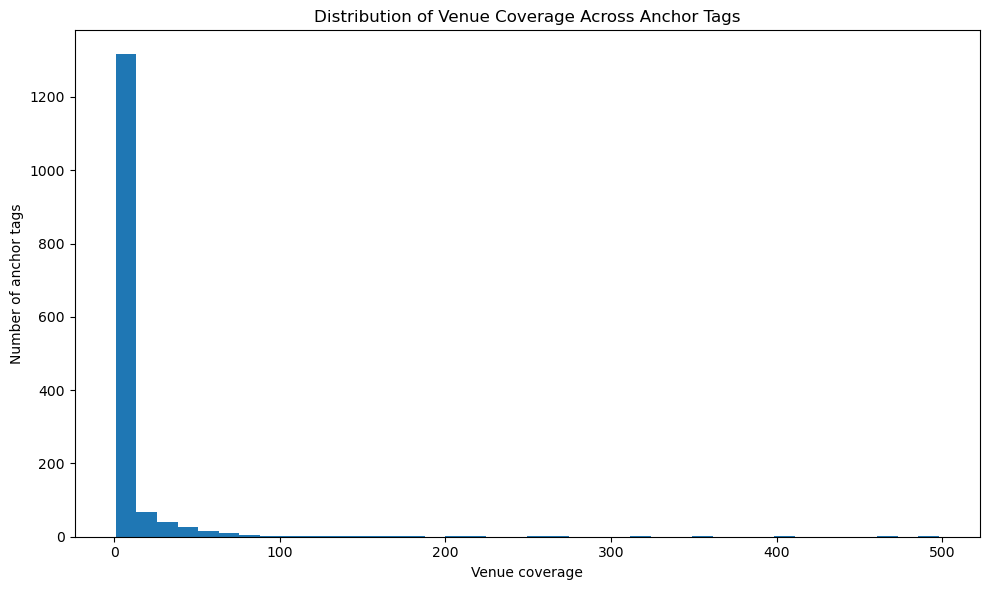

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(anchor_coverage["venue_coverage"].dropna(), bins=40)
plt.xlabel("Venue coverage")
plt.ylabel("Number of anchor tags")
plt.title("Distribution of Venue Coverage Across Anchor Tags")
plt.tight_layout()
plt.show()

To avoid relying on an arbitrary fixed cutoff, we derive the threshold from the observed distribution of venue coverage. Because venue coverage is skewed rather than normally distributed, we use a **robust distribution-based threshold** instead of a mean-based rule.

Here, we define the coverage threshold as:

- **median venue coverage + 1.5 × IQR**

This is a robust rule because it is less sensitive to extreme high-coverage tags and reflects the typical spread of the data more reliably than the mean. In practice, it helps us keep anchor tags with clearly above-typical venue reach while filtering out candidates that remain too narrow for shortlist review.

#### Define a robust venue-coverage threshold

In [64]:
q1 = anchor_coverage["venue_coverage"].quantile(0.25)
q2 = anchor_coverage["venue_coverage"].quantile(0.50)   # median
q3 = anchor_coverage["venue_coverage"].quantile(0.75)
iqr = q3 - q1

VENUE_COVERAGE_THRESHOLD = q2 + 1.5 * iqr
print("Venue coverage threshold:", VENUE_COVERAGE_THRESHOLD)

Venue coverage threshold: 9.0


In [65]:
anchor_shortlist = anchor_coverage[
    anchor_coverage["venue_coverage"] >= VENUE_COVERAGE_THRESHOLD
].copy()

anchor_shortlist = anchor_shortlist.sort_values(
    ["venue_coverage", "group_total_frequency", "anchor_frequency"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("Anchor tags kept in shortlist:", len(anchor_shortlist))
anchor_shortlist.head(10)

Anchor tags kept in shortlist: 291


,group_id,bucket,anchor_tag,anchor_frequency,group_total_frequency,venue_coverage,venue_tag_rows
0,348,food_quality,delicious food,2489,11875,498,2295
1,0,service_operations,excellent service,2597,8639,464,1188
2,1,service_operations,friendly staff,2472,7615,401,1416
3,1251,ambiance_noise,great atmosphere,707,5274,352,889
4,2,service_operations,fast service,1271,4469,318,626
5,1541,price_value,reasonable prices,599,4087,272,761
6,1694,alcohol_smoking,great drinks,488,3760,270,832
7,1026,seating_space,small venue,221,1031,252,417
8,3,service_operations,attentive service,1168,1695,216,374
9,1024,seating_space,outdoor seating,776,3008,206,707


In [66]:
list(anchor_shortlist["anchor_tag"])

['delicious food',
 'excellent service',
 'friendly staff',
 'great atmosphere',
 'fast service',
 'reasonable prices',
 'great drinks',
 'small venue',
 'attentive service',
 'outdoor seating',
 'great flavor',
 'fresh ingredients',
 'lacking flavor',
 'great ambiance',
 'unique dishes',
 'consistent quality',
 'good value',
 'good vibes',
 'extensive menu',
 'beautiful decor',
 'unique flavors',
 'coffee',
 'good for friends',
 'disappointing food',
 'family friendly',
 'small space',
 'worth the price',
 'long wait times',
 'craft cocktails',
 'relaxing atmosphere',
 'live music',
 'inconsistent service',
 'delicious tacos',
 'limited parking',
 'exceptional service',
 'overpriced',
 'unfriendly service',
 'great location',
 'attentive waiters',
 'professional service',
 'cozy ambiance',
 'good music',
 'delicious cocktails',
 'mexican food',
 'delicious coffee',
 'friendly servers',
 'casual vibe',
 'inconsistent drinks',
 'tender meat',
 'comfortable place',
 'fresh seafood',
 'in

At this stage, the shortlist should be read as a set of **candidate product signals**, not as a finalized feature taxonomy. Some tags may still be too broad, too vague, too redundant with each other, or too specific to a narrow venue context. That is why a final manual review step is still necessary.

### Step 13. Manual selection with user interview insights

At the final selection stage, some shortlisted anchor tags are converted into simpler user-facing labels. This is a presentation choice rather than a new modeling step: **the goal is to make the final deal-breaker options easier to scan and select in the product UI.**

The manual selection is grounded in the interview insight that GenTags work best as a **decision-support layer**, not as persuasive copy.

Users mainly use tags to **filter and confirm** choices, and they trust them only when the tags are **concrete, practical, and aligned with real decision needs** rather than vague, promotional, or excessive. The report also shows that users typically think **food-first, then constraints and situational context**, and that the highest-utility tags are functional shortcuts such as price, seating, distance, Wi-Fi, or other practical constraints. 

As a result, final manual selection should prioritize anchor tags that help users quickly include or exclude venues in realistic scenarios, especially those tied to confidence, speed, and trust, while deprioritizing broad praise, weak sentiment, overly subjective vibe labels, and narrow item-specific phrases that are less useful for actual venue choice. 

#### Proposed deal-breaker tags with short clarifiers and original-tag examples

- **Price** *(cost, value)*  
  Examples: `reasonable prices`, `overpriced`, `too expensive`, `value for money`

- **Parking** *(availability, convenience)*  
  Examples: `limited parking`

- **Seating** *(outdoor setup, table and space conditions)*  
  Examples: `outdoor seating`, `outdoor patio`, `terrace`

- **Wait time** *(seating delay, food delay)*  
  Examples: `long wait times`, `long wait for food`, `wait to be seated`

- **Reservations** *(booking needed or recommended)*  
  Examples: `reservations recommended`

- **Delivery** *(delivery available)*  
  Examples: `delivery available`, `uber eats`

- **Takeout** *(pickup available)*  
  Examples: `takeout available`

- **Vegan options** *(vegan-friendly choices)*  
  Examples: `vegan options`

- **Healthy options** *(light, healthy, high-protein choices)*  
  Examples: `healthy options`, `health foods`, `high protein options`

- **Menu variety** *(range of options, flexibility)*  
  Examples: `extensive menu`, `wide variety`, `variety of options`

- **Food quality** *(taste, consistency, ingredients)*  
  Examples: `inconsistent food quality`, `food could be better`, `subpar food`, `average food`

- **Food safety** *(hygiene, undercooked food, health concerns)*  
  Examples: `food safety concerns`, `hygiene concerns`, `undercooked crust`

- **Service** *(staff responsiveness, order handling)*  
  Examples: `slow food service`, `disappointing service`, `average service`, `disorganized service`

- **Noise level** *(loudness, music volume)*  
  Examples: `noisy atmosphere`, `noisy venue`, `low music`, `live music`